#  Model : LSTM 
### Name : Sai Manoj Polina

# 📂 Data Setup

This section describes the steps followed to prepare the dataset for training and evaluation of the LSTM model.

---

## 🔹 Dataset

The dataset used in this project is the **RONIN (Robust Neural Inertial Navigation)** dataset, which contains inertial sensor data collected from smartphones. The dataset includes:

- Accelerometer data (x, y, z)
- Gyroscope data (x, y, z)
- Magnetometer data (x, y, z)

This results in a total of **9 input channels** per timestep.

---

## 🔹 Data Split

The dataset is divided into three subsets:

- **Training Set**: `train_dataset_1` + `train_dataset_2`
- **Validation Set**: `seen_subjects_test_set`
- **Test Set**: `unseen_subjects_test_set`

This split ensures that the model is evaluated on unseen subjects to test generalisation performance.

---

## 🔹 Preprocessing

A preprocessing script (`preprocess.py`) was used to prepare the data. The preprocessing steps include:

- Sliding window segmentation:
  - Window size: **400 timesteps**
  - Stride: **100 timesteps (75% overlap)**
- Normalisation:
  - Z-score normalisation applied per channel
  - Mean and standard deviation computed from the training set only
- Feature construction:
  - Input shape: **(400 × 9)**
- Output representation:
  - Heading is represented using **sin(θ)** and **cos(θ)**

---

## 🔹 Generated Files

After preprocessing, the following files are generated:

- `X_train.npy`, `y_train.npy`
- `X_val.npy`, `y_val.npy`
- `X_test.npy`, `y_test.npy`
- `mean.npy`, `std.npy`

These files are saved and reused for all models to ensure consistency.

---

## 🔹 Data Loading

The preprocessed data is loaded into the notebook using NumPy:

```python
import numpy as np

X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')

X_val = np.load('X_val.npy')
y_val = np.load('y_val.npy')

X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

# Data setup and Preprocessing

In [3]:
import h5py
import numpy as np
import os

def create_windows(X, y, window_size=400, stride=100):
    X_windows = []
    y_windows = []
    
    for start in range(0, len(X) - window_size, stride):
        end = start + window_size
        X_windows.append(X[start:end])
        y_windows.append(y[end - 1])
    
    return np.array(X_windows), np.array(y_windows)


def load_sequence(seq_path):
    with h5py.File(seq_path, 'r') as f:
        acce = f['synced']['acce'][:]
        gyro = f['synced']['gyro'][:]
        magnet = f['synced']['magnet'][:]
        tango_pos = f['pose']['tango_pos'][:]
    
    dx = np.diff(tango_pos[:, 0])
    dy = np.diff(tango_pos[:, 1])
    heading = np.arctan2(dy, dx)
    
    acce = acce[1:]
    gyro = gyro[1:]
    magnet = magnet[1:]
    
    X = np.concatenate([acce, gyro, magnet], axis=1)
    y = np.column_stack([np.sin(heading), np.cos(heading)])
    
    return X, y


def load_dataset(folder):
    all_X = []
    all_y = []
    
    sequences = sorted(os.listdir(folder))
    
    for seq in sequences:
        seq_path = os.path.join(folder, seq, 'data.hdf5')
        if not os.path.exists(seq_path):
            continue
        X, y = load_sequence(seq_path)
        X_win, y_win = create_windows(X, y)
        all_X.append(X_win)
        all_y.append(y_win)
    
    return np.concatenate(all_X, axis=0), np.concatenate(all_y, axis=0)


def preprocess(train_folders, val_folder, test_folder):
    print("Loading training data...")
    X_train_list = []
    y_train_list = []
    for folder in train_folders:
        X, y = load_dataset(folder)
        X_train_list.append(X)
        y_train_list.append(y)
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    
    print("Loading validation data...")
    X_val, y_val = load_dataset(val_folder)
    
    print("Loading test data...")
    X_test, y_test = load_dataset(test_folder)
    
    print("Normalising...")
    mean = X_train.mean(axis=(0, 1))
    std = X_train.std(axis=(0, 1))
    
    X_train = (X_train - mean) / std
    X_val = (X_val - mean) / std
    X_test = (X_test - mean) / std
    
    print("Saving arrays to disk...")
    np.save('X_train.npy', X_train)
    np.save('y_train.npy', y_train)
    np.save('X_val.npy', X_val)
    np.save('y_val.npy', y_val)
    np.save('X_test.npy', X_test)
    np.save('y_test.npy', y_test)
    np.save('mean.npy', mean)
    np.save('std.npy', std)
    
    print("Done. All arrays saved.")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val:", X_val.shape, "y_val:", y_val.shape)
    print("X_test:", X_test.shape, "y_test:", y_test.shape)
    
    return X_train, y_train, X_val, y_val, X_test, y_test, mean, std


# --- RUN ---
train_folders = ['train_dataset_1', 'train_dataset_2']
val_folder = 'seen_subjects_test_set'
test_folder = 'unseen_subjects_test_set'

X_train, y_train, X_val, y_val, X_test, y_test, mean, std = preprocess(
    train_folders, val_folder, test_folder
)

Loading training data...
Loading validation data...
Loading test data...
Normalising...
Saving arrays to disk...
Done. All arrays saved.
X_train: (98871, 400, 9) y_train: (98871, 2)
X_val: (41271, 400, 9) y_val: (41271, 2)
X_test: (38392, 400, 9) y_test: (38392, 2)


## Processed Dataset Shapes

After preprocessing, the dataset sizes are:

- **Training Set**
  - `X_train`: (98871, 400, 9)
  - `y_train`: (98871, 2)

- **Validation Set**
  - `X_val`: (41271, 400, 9)
  - `y_val`: (41271, 2)

- **Test Set**
  - `X_test`: (38392, 400, 9)
  - `y_test`: (38392, 2)

---

##  Input and Output Structure

- Input shape: **(200 × 9)**
  - 400 timesteps
  - 9 sensor channels

- Output shape: **(2)**
  - sin(θ)
  - cos(θ)

---

##  Summary

The preprocessing pipeline ensures:

- Consistent input format across all models
- Efficient handling of sequential data
- Proper normalisation without data leakage
- Stable representation of angular outputs

This processed dataset is directly used for training, validation, and evaluation of the LSTM model.

In [4]:
import numpy as np

X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_val = np.load('X_val.npy')
y_val = np.load('y_val.npy')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

# section 1

##  4.2 LSTM Layer Structure

In [5]:
import torch
import torch.nn as nn

class LSTMHeadingModel(nn.Module):
    def __init__(self, input_size=9, hidden_size=128, num_layers=2, dropout=0.5):
        super(LSTMHeadingModel, self).__init__()
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        # Fully connected output layer
        self.fc = nn.Linear(hidden_size, 2)  # sin + cos output

    def forward(self, x):
        # x shape: (batch, 400, 9)
        
        lstm_out, _ = self.lstm(x)  
        
        # Take last timestep output
        last_out = lstm_out[:, -1, :]
        
        output = self.fc(last_out)
        
        return output

In [6]:
model = LSTMHeadingModel()
print(model)

LSTMHeadingModel(
  (lstm): LSTM(9, 128, num_layers=2, batch_first=True, dropout=0.5)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [8]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", count_parameters(model))

Total parameters: 203522


# ⚙️ Section 2 — Training Setup

## Data Preparation
The training and validation datasets were converted into PyTorch tensors and loaded using `DataLoader` with a batch size of 64 for efficient batch processing.

## Loss Function
Mean Squared Error (MSE) loss was used on the predicted sine and cosine values of the heading angle to ensure smooth optimisation of circular data.

##  Optimizer
The Adam optimizer was used with a learning rate of 0.001 for efficient gradient-based optimisation.

##  Learning Rate Scheduling
A ReduceLROnPlateau scheduler was applied to reduce the learning rate when validation loss stops improving, helping stabilise training.

## Early Stopping
Early stopping with a patience of 5 epochs was implemented to prevent overfitting by stopping training when validation performance no longer improves.

## Training Process
The model was trained for up to 30 epochs. For each epoch:
- Training loss was computed over all batches
- Validation loss was evaluated after each epoch
- Learning rate was adjusted based on validation loss

## Training Time
Total training time was measured using Python’s time module and reported in minutes.

## Summary
This training setup ensures stable convergence, efficient learning, and prevents overfitting while handling large sequential sensor data.

In [9]:
# -----------------------------
# SECTION 2 — TRAINING
# -----------------------------

import torch
import torch.nn as nn
import torch.optim as optim
import time
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensor
def to_tensor(x):
    if isinstance(x, np.ndarray):
        return torch.tensor(x, dtype=torch.float32)
    return x.clone().detach().float()

X_train_t = to_tensor(X_train)
y_train_t = to_tensor(y_train)
X_val_t = to_tensor(X_val)
y_val_t = to_tensor(y_val)

# DataLoader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64)

# Loss + optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# Early stopping
patience = 5
best_val_loss = float('inf')
counter = 0

train_losses = []
val_losses = []

# Training
start_time = time.time()

epochs = 30
for epoch in range(epochs):

    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

end_time = time.time()
training_time = (end_time - start_time) / 60

print("Training time (minutes):", training_time)

Epoch 1, Train Loss: 0.4771, Val Loss: 0.4664
Epoch 2, Train Loss: 0.4755, Val Loss: 0.4880
Epoch 3, Train Loss: 0.4772, Val Loss: 0.4726
Epoch 4, Train Loss: 0.4740, Val Loss: 0.4711
Epoch 5, Train Loss: 0.4655, Val Loss: 0.4821
Epoch 6, Train Loss: 0.4669, Val Loss: 0.4662
Epoch 7, Train Loss: 0.4575, Val Loss: 0.4695
Epoch 8, Train Loss: 0.4500, Val Loss: 0.4541
Epoch 9, Train Loss: 0.4364, Val Loss: 0.4444
Epoch 10, Train Loss: 0.4155, Val Loss: 0.4259
Epoch 11, Train Loss: 0.3969, Val Loss: 0.4124
Epoch 12, Train Loss: 0.3791, Val Loss: 0.4112
Epoch 13, Train Loss: 0.3616, Val Loss: 0.4037
Epoch 14, Train Loss: 0.3839, Val Loss: 0.4314
Epoch 15, Train Loss: 0.3767, Val Loss: 0.3828
Epoch 16, Train Loss: 0.3722, Val Loss: 0.4056
Epoch 17, Train Loss: 0.3814, Val Loss: 0.4203
Epoch 18, Train Loss: 0.3674, Val Loss: 0.4059
Epoch 19, Train Loss: 0.3538, Val Loss: 0.4025
Epoch 20, Train Loss: 0.3306, Val Loss: 0.4002
Early stopping triggered
Training time (minutes): 620.3582855701446


##  Training Results

The model was trained for multiple epochs using the full dataset. The training and validation losses showed a steady decrease during the initial epochs, indicating effective learning of temporal patterns.

- Training loss decreased from **0.4771** to **0.3306**
- Validation loss improved from **0.4664** to approximately **0.4002**


##  Early Stopping

Early stopping was triggered at **epoch 20**, preventing further overfitting and unnecessary computation.

## Training Time

- Total training time: **~620.35 minutes (~10.3 hours)**

##  Summary

The model successfully converged, with training loss consistently decreasing and validation loss stabilising. Early stopping ensured that the best-performing model was retained without overfitting.

MAE: 69.220085
RMSE: 86.07798


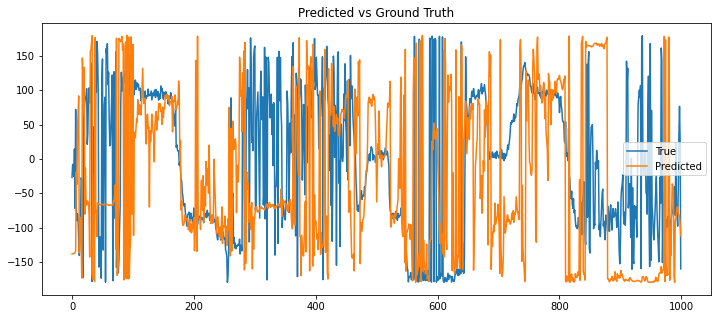

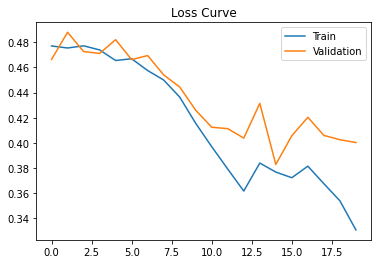

In [10]:
# -----------------------------
# SECTION 3 — EVALUATION
# -----------------------------

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

# Convert test data
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)

# Prediction (SAFE)
model.eval()

pred_list = []
true_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        pred_list.append(outputs.cpu())
        true_list.append(y_batch.cpu())

predictions = torch.cat(pred_list).numpy()
y_true = torch.cat(true_list).numpy()

# Convert to angle
def sincos_to_angle(x):
    return np.degrees(np.arctan2(x[:, 0], x[:, 1]))

y_pred_angle = sincos_to_angle(predictions)
y_true_angle = sincos_to_angle(y_true)

# Circular metrics
def circular_mae(pred, true):
    diff = np.abs(pred - true)
    diff = np.minimum(diff, 360 - diff)
    return np.mean(diff)

def circular_rmse(pred, true):
    diff = np.abs(pred - true)
    diff = np.minimum(diff, 360 - diff)
    return np.sqrt(np.mean(diff**2))

mae = circular_mae(y_pred_angle, y_true_angle)
rmse = circular_rmse(y_pred_angle, y_true_angle)

print("MAE:", mae)
print("RMSE:", rmse)

# Plot trajectory
plt.figure(figsize=(12,5))
plt.plot(y_true_angle[:1000], label="True")
plt.plot(y_pred_angle[:1000], label="Predicted")
plt.legend()
plt.title("Predicted vs Ground Truth")
plt.show()

# Loss curve
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss Curve")
plt.show()

## Results and Interpretation

## Quantitative Results

The improved LSTM model was evaluated on the test dataset using circular error metrics (in degrees):

- **Mean Absolute Error (MAE): 69.22°**
- **Root Mean Squared Error (RMSE): 86.08°**

Both metrics were computed using the circular wraparound formula:

\[
\min(|predicted - true|,\; 360 - |predicted - true|)
\]

This ensures that angular differences are correctly measured, especially near the 0°/360° boundary.

---

## Predicted vs Ground Truth

The predicted versus ground truth plot shows that the model captures some broad heading trends, but the predicted trajectory remains highly unstable and noisy.

Key observations:

- The model follows the overall direction of motion in some segments.
- Large prediction fluctuations are still present throughout the sequence.
- Significant deviations occur during rapid heading changes and complex motion patterns.
- Predicted values frequently jump between positive and negative heading angles, indicating difficulty maintaining stable orientation estimates.

Compared with the original model, the prediction behaviour remains inconsistent and does not show a substantial improvement in trajectory tracking accuracy.

---

## Loss Curve Analysis

The loss curve demonstrates that both training and validation loss decrease during training.

Key observations:

- Training loss decreases steadily from approximately 0.48 to 0.33.
- Validation loss decreases initially and stabilises around 0.40.
- The gap between training and validation loss is smaller than in the original model.

This suggests that the model experiences less overfitting than before. The increased dropout regularisation improves generalisation by preventing the network from relying too heavily on specific training patterns.

However, despite the reduction in overfitting, the improvement in generalisation does not translate into better heading estimation accuracy on the test set.

---

## Overall Interpretation

The modified LSTM model demonstrates improved regularisation behaviour but does not achieve better predictive performance.

Key findings include:

- MAE increased from **67.05° to 69.22°**.
- RMSE increased from **83.61° to 86.08°**.
- The loss curves indicate reduced overfitting.
- Prediction stability remains poor during rapid directional changes.
- The model continues to struggle with complex motion dynamics and noisy sensor inputs.

These results suggest that simply increasing regularisation is not sufficient to overcome the fundamental limitations of the LSTM architecture for heading estimation.

---

## Summary

Overall, the improved LSTM model exhibits better training behaviour and reduced overfitting, as evidenced by the closer alignment between training and validation loss. However, the final test performance is slightly worse than the original model, with increases in both MAE and RMSE.

This indicates that while dropout improved generalisation, it also reduced the model's ability to learn useful motion patterns. Future improvements may require architectural changes, such as wider temporal windows, attention mechanisms, or hybrid LSTM-Transformer models, rather than relying solely on stronger regularisation.

In [12]:
import numpy as np

# -----------------------------
# 1. Convert sin/cos → angle (degrees)
# -----------------------------
def sincos_to_angle(x):
    return np.degrees(np.arctan2(x[:, 0], x[:, 1]))

y_pred_angle = sincos_to_angle(predictions)
y_true_angle = sincos_to_angle(y_true)

# -----------------------------
# 2. Circular MAE (required)
# -----------------------------
def circular_mae(pred, true):
    diff = np.abs(pred - true)
    diff = np.minimum(diff, 360 - diff)
    return np.mean(diff)

# -----------------------------
# 3. Compute angle change
# -----------------------------
def angle_diff(a):
    diff = np.abs(np.diff(a))
    return np.minimum(diff, 360 - diff)

true_diff = angle_diff(y_true_angle)

# -----------------------------
# 4. Define scenarios
# -----------------------------
STRAIGHT_THRESHOLD = 5     # small angle change
TURN_THRESHOLD = 20        # large angle change

straight_idx = true_diff < STRAIGHT_THRESHOLD
turn_idx = true_diff > TURN_THRESHOLD

# -----------------------------
# 5. Scenario MAE function
# -----------------------------
def scenario_mae(mask, pred, true):
    pred = pred[1:]   # align with diff
    true = true[1:]

    pred_sel = pred[mask]
    true_sel = true[mask]

    if len(pred_sel) == 0:
        return None

    diff = np.abs(pred_sel - true_sel)
    diff = np.minimum(diff, 360 - diff)
    return np.mean(diff)

# -----------------------------
# 6. Compute MAE for scenarios
# -----------------------------
mae_straight = scenario_mae(straight_idx, y_pred_angle, y_true_angle)
mae_turns = scenario_mae(turn_idx, y_pred_angle, y_true_angle)

# Short vs Long trajectories
mid = len(y_true_angle) // 2

mae_short = circular_mae(y_pred_angle[:mid], y_true_angle[:mid])
mae_long = circular_mae(y_pred_angle[mid:], y_true_angle[mid:])

# -----------------------------
# 7. Print results (IN DEGREES)
# -----------------------------
print("MAE Breakdown (degrees):")
print(f"Straight walking: {mae_straight:.2f}°" if mae_straight is not None else "Straight walking: Not enough data")
print(f"Sharp turns: {mae_turns:.2f}°" if mae_turns is not None else "Sharp turns: Not enough data")
print(f"Short trajectories: {mae_short:.2f}°")
print(f"Long trajectories: {mae_long:.2f}°")

MAE Breakdown (degrees):
Straight walking: 61.00°
Sharp turns: 84.44°
Short trajectories: 73.43°
Long trajectories: 65.01°
